In [1]:
%run nb1_setup.ipynb

# Notebook 4: Category Distributions & Internal Consistency

**Distributions** pool all 4 repeats (LLM-only analysis). **Consistency** uses repeat=0.

In [2]:
import os
for _r in range(4):
    os.makedirs(f"repeat_{_r}", exist_ok=True)
os.makedirs("all_repeats", exist_ok=True)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

def save_category_distribution_per_llm(feedback_df, hash_column='reaction_hash',
                output_dir='all_repeats/human_vs_llm_analysis_reruns',
                category_column='local_feedback',
                expert_column='source_file',
                llm_order=("Claude Opus 4.8", "Gemini 3.1 Pro", "GPT-5.5", "Llama 3.1 70B"),
                truncate=55,
                figsize=(12, 7),
                sort_by='count'):
    """
    Save category distribution plots for:
    1. Each LLM (all runs) with human baseline - using consistent scale
    2. Human distribution
    3. Combined comparison plots
    
    Parameters:
    - feedback_df: DataFrame containing all evaluations
    - hash_column: 'reaction_hash' or 'route_hash' to determine analysis type
    - output_dir: directory to save outputs
    - category_column: column with category labels
    - expert_column: column with model identifier (LLM name)
    - llm_order: tuple/list of LLMs to plot and their order
    - truncate: max characters for category label display
    - figsize: figure size for each plot
    - sort_by: 'percentage' or 'count' to sort bars
    """
    os.makedirs(output_dir, exist_ok=True)
    
    # Get mappings for this analysis type
    mappings = CategoryMappings.get_mappings(hash_column)
    aliases = mappings.get('aliases', {})
    hierarchy = mappings['hierarchy']
    
    # Separate human and LLM data
    human_df = feedback_df[~feedback_df[expert_column].isin(llm_order)].copy()
    llm_df = feedback_df[feedback_df[expert_column].isin(llm_order)].copy()
    
    if llm_df.empty:
        print("No LLM rows found for the specified llm_order.")
        return
    
    # Calculate human baseline distribution (simple vote counting)
    human_baseline = _calculate_human_distribution(human_df, category_column)
    
    # Get all categories and determine global scale
    all_categories = set(llm_df[category_column].dropna().unique())
    all_categories.update(human_baseline.keys())
    categories = list(all_categories)
    categories.sort(key=lambda x: (-hierarchy.get(x, -np.inf), x))
    
    # Calculate max percentage across all LLMs and humans for consistent scale
    max_percentage = _calculate_global_max_percentage(llm_df, human_baseline, llm_order, 
                                                     categories, category_column, expert_column)
    
    # Save human distribution plot
    _save_human_distribution_plot(human_baseline, aliases, hierarchy, output_dir, 
                                 figsize, sort_by, max_percentage)
    
    # Process each LLM with consistent scale
    for llm in llm_order:
        llm_sub = llm_df[llm_df[expert_column] == llm]
        if llm_sub.empty:
            print(f"No rows for LLM: {llm}")
            _save_empty_plot(llm, output_dir)
            continue
        
        # All runs distribution with human baseline and consistent scale
        _save_llm_distribution(llm_sub, llm, human_baseline, aliases, hierarchy, 
                              category_column, output_dir, figsize, sort_by, 
                              categories, max_percentage)
    
    # Combined comparison plots
    _save_combined_distribution_plots(llm_df, human_baseline, llm_order, aliases, hierarchy,
                                     category_column, output_dir, figsize, sort_by, categories)

def _calculate_global_max_percentage(llm_df, human_baseline, llm_order, categories, 
                                   category_column, expert_column):
    """Calculate the maximum percentage across all LLMs and humans for consistent scaling"""
    max_percentages = []
    
    # Add human max
    if human_baseline:
        max_percentages.append(max(human_baseline.values()))
    
    # Add each LLM max
    for llm in llm_order:
        llm_sub = llm_df[llm_df[expert_column] == llm]
        if not llm_sub.empty:
            counts = llm_sub[category_column].value_counts()
            total = counts.sum()
            if total > 0:
                percentages = (counts / total * 100.0)
                max_percentages.append(percentages.max())
    
    # Return max with some padding for better visualization
    global_max = max(max_percentages) if max_percentages else 100
    return min(100, global_max * 1.1)  # Add 10% padding, cap at 100%

def _calculate_human_distribution(human_df, category_column):
    """Calculate human category distribution by counting all votes"""
    if human_df.empty:
        return {}
    
    # Simple vote counting - count every category selection by humans
    counts = human_df[category_column].value_counts()
    total = counts.sum()
    
    if total == 0:
        return {}
    
    return {cat: (count / total * 100.0) for cat, count in counts.items()}

def _save_human_distribution_plot(human_baseline, aliases, hierarchy, output_dir, 
                                 figsize, sort_by, max_percentage):
    """Save human distribution plot with consistent scale"""
    if not human_baseline:
        return
    
    # Order categories by hierarchy
    categories = list(human_baseline.keys())
    categories.sort(key=lambda x: (-hierarchy.get(x, -np.inf), x))
    
    percentages = [human_baseline[cat] for cat in categories]
    alias_labels = [aliases.get(cat, cat) for cat in categories]
    
    plt.figure(figsize=figsize)
    bars = plt.bar(range(len(categories)), percentages, color='darkgreen', alpha=0.7, edgecolor='black')
    plt.title('Human Expert Distribution (All Votes)', fontsize=16, fontweight='bold')
    plt.ylabel('Percentage (%)', fontsize=14)
    plt.ylim(0, max_percentage)  # Set consistent scale
    plt.xticks(range(len(alias_labels)), alias_labels, rotation=45, fontsize=12, ha='right')
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Annotate bars
    for i, bar in enumerate(bars):
        height = bar.get_height()
        if height >= max_percentage * 0.02:  # Annotate if >= 2% of max scale
            plt.text(bar.get_x() + bar.get_width()/2., height + max_percentage * 0.01, f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'category_distribution_humans.png'), dpi=300, bbox_inches='tight')
    plt.close()
    
    # Save CSV
    human_df = pd.DataFrame({
        'category': categories,
        'percentage': percentages
    })
    human_df.to_csv(os.path.join(output_dir, 'category_distribution_humans.csv'), index=False)

def _save_llm_distribution(llm_sub, llm_name, human_baseline, aliases, hierarchy,
                          category_column, output_dir, figsize, sort_by, 
                          categories, max_percentage):
    """Save LLM distribution for all runs with human baseline and consistent scale"""
    counts = llm_sub[category_column].value_counts()
    total = counts.sum()
    percentages = (counts / total * 100.0).round(1)
    
    # Use the provided categories order (already sorted by hierarchy)
    llm_percentages = [percentages.get(cat, 0) for cat in categories]
    human_percentages = [human_baseline.get(cat, 0) for cat in categories]
    alias_labels = [aliases.get(cat, cat) for cat in categories]
    
    # Create table and save CSV
    table = pd.DataFrame({
        'category': categories,
        'count': [counts.get(cat, 0) for cat in categories],
        'percentage': llm_percentages,
        'human_baseline_percentage': human_percentages
    })
    table.to_csv(os.path.join(output_dir, f'category_distribution_{llm_name}.csv'), index=False)
    
    # Plot with consistent scale
    plt.figure(figsize=figsize)
    x_pos = np.arange(len(categories))
    
    bars = plt.bar(x_pos, llm_percentages, color='steelblue', alpha=0.8, 
                   edgecolor='black',) #label=f'{llm_name}')
    
    # Add human baseline as dashed line for "Reaction feasible, all good"
    target_category = "Reaction feasible, all good"
    if target_category in categories and target_category in human_baseline:
        human_value = human_baseline[target_category]
        plt.axhline(y=human_value, color='darkgreen', linestyle='--', linewidth=2, )
        #           label=f'Human Baseline ({target_category}): {human_value:.1f}%')
    
    plt.title(f'{llm_name}', fontsize=18, fontweight='bold')
    plt.ylabel('Percentage (%)', fontsize=16)
    plt.ylim(0, max_percentage)  # Set consistent scale
    plt.xticks(x_pos, alias_labels, rotation=45, fontsize=16, ha='right')
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.legend(fontsize=12)
    
    # Annotate bars
    for i, bar in enumerate(bars):
        height = bar.get_height()
        if height >= max_percentage * 0.02:  # Annotate if >= 2% of max scale
            plt.text(bar.get_x() + bar.get_width()/2., height + max_percentage * 0.01, f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=16)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'category_distribution_{llm_name}.png'), 
                dpi=300, bbox_inches='tight')
    plt.close()

def _save_combined_distribution_plots(llm_df, human_baseline, llm_order, aliases, hierarchy,
                                     category_column, output_dir, figsize, sort_by, categories):
    """Save combined comparison plots"""
    alias_labels = [aliases.get(cat, cat) for cat in categories]
    
    # Combined comparison
    plt.figure(figsize=(15, 8))
    x = np.arange(len(categories))
    width = 0.15
    
    # Human baseline
    human_values = [human_baseline.get(cat, 0) for cat in categories]
    plt.bar(x - 2*width, human_values, width, label='Humans', color='darkgreen', alpha=0.7)
    
    # Each LLM
    colors = ['steelblue', 'orange', 'red', 'purple']
    expert_col = [col for col in llm_df.columns if 'source' in col or 'expert' in col][0]
    
    for i, llm in enumerate(llm_order):
        llm_sub = llm_df[llm_df[expert_col] == llm]
        if not llm_sub.empty:
            counts = llm_sub[category_column].value_counts()
            total = counts.sum()
            percentages = {cat: (counts.get(cat, 0) / total * 100.0) for cat in categories}
            values = [percentages[cat] for cat in categories]
            plt.bar(x + (i-1)*width, values, width, label=f'{llm}', 
                   color=colors[i % len(colors)], alpha=0.7)
    
    plt.title('Category Distribution Comparison', fontsize=16, fontweight='bold')
    plt.ylabel('Percentage (%)', fontsize=14)
    plt.xlabel('Categories', fontsize=14)
    plt.xticks(x, alias_labels, rotation=45, ha='right', fontsize=10)
    plt.legend(fontsize=12, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'category_distribution_comparison.png'), 
                dpi=300, bbox_inches='tight')
    plt.close()
    
    # Save combined data as CSV
    combined_data = {'category': categories}
    combined_data['humans'] = human_values
    
    for llm in llm_order:
        llm_sub = llm_df[llm_df[expert_col] == llm]
        if not llm_sub.empty:
            counts = llm_sub[category_column].value_counts()
            total = counts.sum()
            values = [(counts.get(cat, 0) / total * 100.0) for cat in categories]
            combined_data[llm] = values
        else:
            combined_data[llm] = [0] * len(categories)
    
    combined_df = pd.DataFrame(combined_data)
    combined_df.to_csv(os.path.join(output_dir, 'category_distribution_comparison.csv'), index=False)

def _save_empty_plot(name, output_dir):
    """Save empty placeholder plot"""
    plt.figure(figsize=(8, 3))
    plt.text(0.5, 0.5, f'No data for {name}', ha='center', va='center', fontsize=12)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'category_distribution_{name}.png'), 
                dpi=300, bbox_inches='tight')
    plt.close()

# Usage function
def run_category_distribution_analysis(feedback_csv, hash_column='reaction_hash',
                                     output_dir='all_repeats/category_distribution_analysis',
                                     category_column='local_feedback',
                                     expert_column='source_file',
                                     llm_order=("Claude Opus 4.8", "Gemini 3.1 Pro", "GPT-5.5", "Llama 3.1 70B")):
    """
    Run complete category distribution analysis with consistent scaling
    """
    feedback_df = pd.read_csv(feedback_csv)
    
    analysis_type = 'Reactions' if hash_column == 'reaction_hash' else 'Routes'
    print(f"Starting Category Distribution Analysis - {analysis_type}...")
    print("=" * 50)
    
    save_category_distribution_per_llm(
        feedback_df=feedback_df,
        hash_column=hash_column,
        output_dir=output_dir,
        category_column=category_column,
        expert_column=expert_column,
        llm_order=llm_order
    )
    
    print(f"Results saved to {output_dir}/")

In [15]:
run_category_distribution_analysis(
    'expert_feedback_combined_new_llms.csv',
    hash_column='reaction_hash',
    output_dir='all_repeats/reaction_distributions'
)

Starting Category Distribution Analysis - Reactions...


/scratch/tmp_user_data/kjkh840/ipykernel_2020062/3768318603.py:203: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=12)
/scratch/tmp_user_data/kjkh840/ipykernel_2020062/3768318603.py:203: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=12)
/scratch/tmp_user_data/kjkh840/ipykernel_2020062/3768318603.py:203: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=12)
/scratch/tmp_user_data/kjkh840/ipykernel_2020062/3768318603.py:203: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend(

Results saved to all_repeats/reaction_distributions/


In [16]:
run_category_distribution_analysis(
    'expert_feedback_combined_new_llms.csv',
    hash_column='root_molecule_hash',
    category_column='general_feedback',
    expert_column='source_file',
    output_dir='all_repeats/routes_distributions',
)

Starting Category Distribution Analysis - Routes...


/scratch/tmp_user_data/kjkh840/ipykernel_2020062/3768318603.py:203: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=12)
/scratch/tmp_user_data/kjkh840/ipykernel_2020062/3768318603.py:203: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=12)
/scratch/tmp_user_data/kjkh840/ipykernel_2020062/3768318603.py:203: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=12)
/scratch/tmp_user_data/kjkh840/ipykernel_2020062/3768318603.py:203: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend(

Results saved to all_repeats/routes_distributions/


In [3]:
def _analyze_single_llm_rerun_agreement(reaction_data, reaction_hash, llm_name,
                                       category_column, text_column, confidence_column,
                                       consensus_result, hierarchy, sentiment_mapping):
    """
    Analyze agreement for a single reaction within one LLM's re-runs.
    Uses the consensus result from the existing tie-breaking logic.
    """
    # Collect categories from re-runs
    categories = reaction_data[category_column].dropna().tolist()
    num_runs = len(categories)

    # Get consensus category and agreement percentage from existing logic
    dominant_category = consensus_result['dominant_category']
    category_agreement_pct = consensus_result['agreement_pct']
    
    # Determine agreement level based on percentage
    if category_agreement_pct >= 100 - 1e-9:
        agreement_level = "Perfect"
    elif category_agreement_pct >= 75:
        agreement_level = "Strong"
    elif category_agreement_pct >= 50:
        agreement_level = "Moderate"
    elif category_agreement_pct >= 30:
        agreement_level = "Weak"
    else:
        agreement_level = "None"
        # Print detailed reason for None consensus
        _print_none_consensus_reason(llm_name, reaction_hash, categories, 
                                   consensus_result, category_agreement_pct)

    # Sentiment analysis
    sentiments = [sentiment_mapping.get(c, 'Unknown') for c in categories]
    sent_counts = Counter(sentiments)
    top_sent = sent_counts.most_common(1)[0][0] if sent_counts else 'Unknown'
    sent_agree_pct = (sent_counts.get(top_sent, 0) / num_runs * 100.0) if num_runs > 0 else 0.0

    # Score summary using hierarchy
    run_scores = [hierarchy.get(c, 0) for c in categories]
    score_mean = float(np.mean(run_scores)) if run_scores else 0.0
    score_std = float(np.std(run_scores)) if run_scores else 0.0

    # Optional confidence analysis
    confidences = reaction_data[confidence_column].dropna().tolist() if confidence_column in reaction_data.columns else []
    confidence_mean = np.mean(confidences) if len(confidences) > 0 else None
    confidence_std = np.std(confidences) if len(confidences) > 0 else None

    # Texts
    texts = reaction_data[text_column].dropna().tolist() if text_column in reaction_data.columns else []

    return {
        'llm_name': llm_name,
        'reaction_hash': reaction_hash,
        'num_runs': num_runs,
        'dominant_category': dominant_category,
        'category_agreement_pct': round(category_agreement_pct, 1),
        'dominant_sentiment': top_sent,
        'sentiment_agreement_pct': round(sent_agree_pct, 1),
        'agreement_level': agreement_level,
        'score_mean': round(score_mean, 2),
        'score_std': round(score_std, 2),
        'confidence_mean': round(confidence_mean, 1) if confidence_mean is not None else None,
        'confidence_std': round(confidence_std, 1) if confidence_std is not None else None,
        'category_counts': consensus_result['all_categories'],
        'sentiment_counts': dict(sent_counts),
        'unique_categories': len(consensus_result['all_categories']),
        'unique_sentiments': len(sent_counts),
        'text_feedback': texts,
        'has_disagreement': agreement_level not in ['Perfect']
    }

def _analyze_single_human_agreement(reaction_data, reaction_hash, expert_column,
                                  category_column, text_column, consensus_result,
                                  hierarchy, sentiment_mapping):
    """Analyze agreement for a single reaction among human experts"""
    experts = reaction_data[expert_column].unique()
    num_experts = len(experts)
    
    # Get consensus from existing logic
    dominant_category = consensus_result['dominant_category']
    category_agreement_pct = consensus_result['agreement_pct']
    
    # Determine agreement level
    if category_agreement_pct >= 100 - 1e-9:
        agreement_level = "Perfect"
    elif category_agreement_pct >= 75:
        agreement_level = "Strong"
    elif category_agreement_pct >= 50:
        agreement_level = "Moderate"
    elif category_agreement_pct >= 30:
        agreement_level = "Weak"
    else:
        agreement_level = "None"
        # Print detailed reason for None consensus
        all_categories = []
        for expert in experts:
            expert_data = reaction_data[reaction_data[expert_column] == expert]
            expert_cats = expert_data[category_column].dropna().tolist()
            all_categories.extend(expert_cats)
        _print_none_consensus_reason("Human Experts", reaction_hash, all_categories, 
                                   consensus_result, category_agreement_pct)

    # Collect all categories from all experts (presence voting already handled in consensus)
    all_categories = []
    for expert in experts:
        expert_data = reaction_data[reaction_data[expert_column] == expert]
        expert_cats = expert_data[category_column].dropna().tolist()
        all_categories.extend(expert_cats)
    
    # Sentiment analysis
    sentiments = [sentiment_mapping.get(c, 'Unknown') for c in all_categories]
    sent_counts = Counter(sentiments)
    top_sent = sent_counts.most_common(1)[0][0] if sent_counts else 'Unknown'
    sent_agree_pct = (sent_counts.get(top_sent, 0) / len(sentiments) * 100.0) if sentiments else 0.0

    return {
        'reaction_hash': reaction_hash,
        'num_experts': num_experts,
        'dominant_category': dominant_category,
        'category_agreement_pct': round(category_agreement_pct, 1),
        'dominant_sentiment': top_sent,
        'sentiment_agreement_pct': round(sent_agree_pct, 1),
        'agreement_level': agreement_level,
        'category_counts': consensus_result['all_categories'],
        'sentiment_counts': dict(sent_counts),
        'unique_categories': len(consensus_result['all_categories']),
        'unique_sentiments': len(sent_counts),
        'has_disagreement': agreement_level not in ['Perfect']
    }

def _print_none_consensus_reason(evaluator_name, reaction_hash, categories, consensus_result, agreement_pct):
    """Print detailed reason why consensus is 'None' (< 30% agreement)"""
    print(f"\n{'='*60}")
    print(f"NONE CONSENSUS DETECTED")
    print(f"{'='*60}")
    print(f"Evaluator: {evaluator_name}")
    print(f"Reaction Hash: {reaction_hash}")
    print(f"Agreement Level: {agreement_pct:.1f}% (< 30% threshold)")
    print(f"Total Responses: {len(categories)}")
    print(f"Unique Categories: {len(set(categories))}")
    
    # Show category breakdown
    cat_counts = Counter(categories)
    print(f"\nCategory Distribution:")
    for cat, count in cat_counts.most_common():
        pct = (count / len(categories)) * 100
        print(f"  • {cat}: {count} votes ({pct:.1f}%)")
    
    # Show consensus choice and reasoning
    print(f"\nConsensus Choice: '{consensus_result['dominant_category']}'")
    print(f"Consensus Logic: Pessimistic tie-breaking applied")
    
    # Show why it's problematic
    max_category_pct = max((count / len(categories)) * 100 for count in cat_counts.values())
    print(f"Highest Single Category: {max_category_pct:.1f}%")
    
    if len(set(categories)) == len(categories):
        print("Issue: Complete disagreement - every response different")
    elif max_category_pct < 30:
        print("Issue: No category reaches 30% threshold")
    else:
        print("Issue: High fragmentation across multiple categories")
    
    print(f"{'='*60}\n")

def _create_agreement_pie_chart(data_df, name, color_map, title_suffix, output_dir, agreement_col):
    """Create individual agreement pie chart with improved formatting"""
    dist = data_df[agreement_col].value_counts()
    total = len(data_df)

    plt.figure(figsize=(10, 8))
    if total == 0 or dist.empty:
        plt.pie([1], labels=[f'No eligible {title_suffix.lower()}'], colors=['#CCCCCC'])
        plt.title(f'{name}: Agreement Levels\n(No eligible {title_suffix.lower()})', 
                 fontsize=16, fontweight='bold', pad=20)
    else:
        labels = ['Perfect', 'Strong', 'Moderate', 'Weak', 'None']
        values = [dist.get(l, 0) for l in labels]
        labels_f = [l for l, v in zip(labels, values) if v > 0]
        values_f = [v for v in values if v > 0]
        colors_f = [color_map.get(l, '#CCCCCC') for l in labels_f]
        
        if not values_f:
            plt.pie([1], labels=['No levels'], colors=['#DDDDDD'])
            plt.title(f'{name}: Agreement Levels\n(0 {title_suffix.lower()})', 
                     fontsize=16, fontweight='bold', pad=20)
        else:
            # Create pie chart with better spacing and formatting
            wedges, texts, autotexts = plt.pie(
                values_f, 
                labels=labels_f, 
                autopct=lambda pct: f'{pct:.1f}%' if pct > 3 else '',  # Only show % if > 3%
                colors=colors_f, 
                startangle=0,
                pctdistance=0.65,  # Move percentages closer to edge
                labeldistance=1.05,  # Move labels further from center
                textprops=dict(fontsize=16, fontweight='bold')
            )
            
            # Style the percentage text
            for autotext in autotexts:
                autotext.set_color('black')  # Black text instead of white
                autotext.set_fontweight('bold')
                autotext.set_fontsize(20)
                autotext.set_bbox(dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8, edgecolor='none'))
            
            # Style the label text
            for text in texts:
                text.set_fontsize(16)
                text.set_fontweight('bold')
                text.set_color('black')
            
            # Add a legend for better clarity
            #plt.legend(wedges, [f'{label}: {value} ({value/total*100:.1f}%)' for label, value in zip(labels_f, values_f)],
            #          title="Agreement Levels",
            #          loc="center left",
            #          bbox_to_anchor=(1, 0, 0.5, 1),
            #          fontsize=14)
            
            plt.title(f'{name}\n({total} {title_suffix.lower()})', 
                     fontsize=16, fontweight='bold', pad=20)
    
    # Ensure equal aspect ratio and tight layout
    plt.axis('equal')
    safe_name = name.replace(' ', '_').replace(':', '').replace('-', '_')
    fname = os.path.join(output_dir, f'agreement_levels_{safe_name}.png')
    plt.savefig(fname, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()

def _create_combined_agreement_grid_integrated(reactions_df, human_df, color_map, title_suffix, output_dir):
    """Create combined grid with humans and LLMs with improved formatting"""
    llm_names = reactions_df['llm_name'].unique().tolist()
    total_plots = len(llm_names) + 1  # +1 for humans
    
    if total_plots <= 4:
        rows, cols = 2, 2
        figsize = (16, 12)
    elif total_plots <= 6:
        rows, cols = 2, 3
        figsize = (20, 12)
    else:
        rows = int(np.ceil(total_plots / 4))
        cols = 4
        figsize = (20, 5 * rows)

    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    if total_plots == 1:
        axes = [axes]
    elif rows == 1:
        axes = axes.reshape(1, -1)
    
    plot_idx = 0

    # Human experts subplot
    if plot_idx < len(axes.flat):
        ax = axes.flat[plot_idx]
        dist = human_df['agreement_level'].value_counts()
        total = len(human_df)
        
        if total > 0 and not dist.empty:
            labels = ['Perfect', 'Strong', 'Moderate', 'Weak', 'None']
            values = [dist.get(l, 0) for l in labels]
            labels_f = [l for l, v in zip(labels, values) if v > 0]
            values_f = [v for v in values if v > 0]
            colors_f = [color_map.get(l, '#CCCCCC') for l in labels_f]
            
            if values_f:
                wedges, texts, autotexts = ax.pie(
                    values_f, 
                    labels=labels_f, 
                    autopct=lambda pct: f'{pct:.1f}%' if pct > 5 else '',
                    colors=colors_f, 
                    startangle=90,
                    pctdistance=0.8,
                    wedgeprops=dict(edgecolor='white', linewidth=1.5),
                    textprops=dict(fontsize=10)
                )
                
                # Style percentage text
                for autotext in autotexts:
                    autotext.set_color('black')
                    autotext.set_fontweight('bold')
                    autotext.set_fontsize(11)
                    autotext.set_bbox(dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.9, edgecolor='none'))
                
                # Style labels
                for text in texts:
                    text.set_fontsize(10)
                    text.set_fontweight('bold')
                
                ax.set_title(f'Human Experts\n({total} {title_suffix.lower()})', 
                           fontweight='bold', fontsize=12, pad=15)
            else:
                ax.pie([1], labels=['No levels'], colors=['#DDDDDD'])
                ax.set_title('Human Experts\n(No levels)', fontweight='bold', fontsize=12, pad=15)
        else:
            ax.pie([1], labels=['No data'], colors=['#CCCCCC'])
            ax.set_title('Human Experts\n(No data)', fontweight='bold', fontsize=12, pad=15)
        
        ax.axis('equal')
        plot_idx += 1

    # LLM subplots
    for llm in llm_names:
        if plot_idx >= len(axes.flat):
            break
            
        ax = axes.flat[plot_idx]
        sub = reactions_df[reactions_df['llm_name'] == llm]
        dist = sub['agreement_level'].value_counts()
        total = len(sub)
        
        if total == 0 or dist.empty:
            ax.pie([1], labels=['No data'], colors=['#CCCCCC'])
            ax.set_title(f'{llm}\n(No data)', fontweight='bold', fontsize=12, pad=15)
        else:
            labels = ['Perfect', 'Strong', 'Moderate', 'Weak', 'None']
            values = [dist.get(l, 0) for l in labels]
            labels_f = [l for l, v in zip(labels, values) if v > 0]
            values_f = [v for v in values if v > 0]
            colors_f = [color_map.get(l, '#CCCCCC') for l in labels_f]
            
            if not values_f:
                ax.pie([1], labels=['No levels'], colors=['#DDDDDD'])
                ax.set_title(f'{llm}\n(No levels)', fontweight='bold', fontsize=12, pad=15)
            else:
                wedges, texts, autotexts = ax.pie(
                    values_f, 
                    labels=labels_f, 
                    autopct=lambda pct: f'{pct:.1f}%' if pct > 5 else '',
                    colors=colors_f, 
                    startangle=90,
                    pctdistance=0.8,
                    wedgeprops=dict(edgecolor='white', linewidth=1.5),
                    textprops=dict(fontsize=10)
                )
                
                # Style percentage text
                for autotext in autotexts:
                    autotext.set_color('black')
                    autotext.set_fontweight('bold')
                    autotext.set_fontsize(11)
                    autotext.set_bbox(dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.9, edgecolor='none'))
                
                # Style labels
                for text in texts:
                    text.set_fontsize(10)
                    text.set_fontweight('bold')
                
                ax.set_title(f'{llm}\n({total} {title_suffix.lower()})', 
                           fontweight='bold', fontsize=12, pad=15)
        
        ax.axis('equal')
        plot_idx += 1

    # Hide unused subplots
    for idx in range(plot_idx, len(axes.flat)):
        axes.flat[idx].set_visible(False)

    # Add overall legend
    legend_elements = [plt.Rectangle((0,0),1,1, facecolor=color_map[level], edgecolor='white', linewidth=1) 
                      for level in ['Perfect', 'Strong', 'Moderate', 'Weak', 'None']]
    fig.legend(legend_elements, ['Perfect (100%)', 'Strong (75-99%)', 'Moderate (50-74%)', 'Weak (30-49%)', 'None (<30%)'],
              loc='center', bbox_to_anchor=(0.5, 0.02), ncol=5, fontsize=12, frameon=True, fancybox=True, shadow=True)

    plt.suptitle(f'Agreement Levels Comparison - {title_suffix}', fontsize=18, fontweight='bold', y=0.95)
    plt.tight_layout(rect=[0, 0.08, 1, 0.92])
    fname = os.path.join(output_dir, f'agreement_levels_combined_{title_suffix.lower()}.png')
    plt.savefig(fname, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()

def analyze_llm_internal_agreement(feedback_df, hash_column='reaction_hash',
                                 category_column='local_feedback',
                                 expert_column='source_file',
                                 text_column='local_feedback_text',
                                 confidence_column='confidence',
                                 min_runs=2,
                                 llm_order=("Claude Opus 4.8", "Gemini 3.1 Pro", "GPT-5.5", "Llama 3.1 70B"),
                                 llm_repeat=0):
    """
    Analyze internal agreement within LLM re-runs using existing tie-breaking rules.
    Integrated with the refactored analyzer architecture.
    """
    # Initialize analyzers with correct mappings
    group_analyzer = GroupConsensusAnalyzer(hash_column)
    mappings = CategoryMappings.get_mappings(hash_column)
    hierarchy = mappings['hierarchy']
    sentiment_mapping = mappings['sentiment']
    
    feedback_df = feedback_df.dropna(subset=[hash_column])
    llm_feedback = feedback_df[feedback_df[expert_column].isin(llm_order)].copy()

    # Keep only the chosen repeat so LLMs have the same vote count as one
    # independent run (4 reruns), symmetric with the human expert pool.
    if llm_repeat is not None and 'repeat' in llm_feedback.columns:
        llm_feedback = llm_feedback[llm_feedback['repeat'] == llm_repeat].copy()

    if llm_feedback.empty:
        print("No LLM feedback found for the specified models.")
        return {}

    print(f"Analyzing re-runs for {len(llm_feedback[expert_column].unique())} LLMs")
    print(f"Total LLM feedback entries: {len(llm_feedback)}")

    # Build list of valid LLM-reaction sets with at least min_runs
    valid_llm_reactions = []
    for llm in llm_order:
        df_llm = llm_feedback[llm_feedback[expert_column] == llm]
        for reaction_hash, group in df_llm.groupby(hash_column):
            n_runs = group[category_column].dropna().shape[0]
            if n_runs >= min_runs:
                valid_llm_reactions.append((llm, reaction_hash))

    print(f"LLM-reaction pairs with {min_runs}+ re-runs: {len(valid_llm_reactions)}")
    if not valid_llm_reactions:
        print(f"No LLM-reaction pairs found with at least {min_runs} re-runs.")
        return {}

    reaction_analyses = []

    for llm, reaction_hash in valid_llm_reactions:
        reaction_data = llm_feedback[(llm_feedback[expert_column] == llm) & 
                                   (llm_feedback[hash_column] == reaction_hash)]
        
        # Use existing group consensus logic for consistency
        consensus_result = group_analyzer.get_group_consensus(
            reaction_data, expert_column, category_column, text_column, confidence_column
        )
        
        # Analyze agreement within this LLM's re-runs for this reaction
        reaction_analysis = _analyze_single_llm_rerun_agreement(
            reaction_data, reaction_hash, llm, category_column, text_column, 
            confidence_column, consensus_result, hierarchy, sentiment_mapping
        )
        reaction_analyses.append(reaction_analysis)

    reactions_df = pd.DataFrame(reaction_analyses)

    # Calculate overall statistics for pie charts
    overall_stats = _calculate_llm_rerun_statistics(reactions_df)

    analysis = {
        'reactions_df': reactions_df,
        'overall_statistics': overall_stats
    }

    return analysis

def _calculate_llm_rerun_statistics(reactions_df):
    """Calculate basic statistics needed for visualizations"""
    total_reactions = len(reactions_df)
    
    if total_reactions == 0:
        return {
            'total_reactions': 0,
            'agreement_level_distribution': {},
            'agreement_level_percentage': {}
        }
    
    # Agreement level distribution
    agreement_dist = reactions_df['agreement_level'].value_counts()
    agreement_dist_pct = (agreement_dist / total_reactions * 100).round(1)
    
    return {
        'total_reactions': total_reactions,
        'agreement_level_distribution': agreement_dist.to_dict(),
        'agreement_level_percentage': agreement_dist_pct.to_dict(),
        'average_runs_per_reaction': round(reactions_df['num_runs'].mean(), 1) if 'num_runs' in reactions_df.columns else 0.0
    }

def analyze_human_internal_agreement(feedback_df, hash_column='reaction_hash',
                                   category_column='local_feedback',
                                   expert_column='source_file',
                                   text_column='local_feedback_text',
                                   min_experts=2,
                                   llm_order=("Claude Opus 4.8", "Gemini 3.1 Pro", "GPT-5.5", "Llama 3.1 70B")):
    """
    Analyze internal agreement among human experts using existing tie-breaking rules.
    """
    # Initialize analyzers
    group_analyzer = GroupConsensusAnalyzer(hash_column)
    mappings = CategoryMappings.get_mappings(hash_column)
    hierarchy = mappings['hierarchy']
    sentiment_mapping = mappings['sentiment']
    
    feedback_df = feedback_df.dropna(subset=[hash_column])
    human_feedback = feedback_df[~feedback_df[expert_column].isin(llm_order)].copy()

    if human_feedback.empty:
        print("No human feedback found.")
        return {}

    print(f"Analyzing agreement for {len(human_feedback[expert_column].unique())} human experts")
    print(f"Total human feedback entries: {len(human_feedback)}")

    # Find reactions with multiple human experts
    valid_reactions = []
    for reaction_hash, group in human_feedback.groupby(hash_column):
        n_experts = len(group[expert_column].unique())
        if n_experts >= min_experts:
            valid_reactions.append(reaction_hash)

    print(f"Reactions with {min_experts}+ human experts: {len(valid_reactions)}")
    if not valid_reactions:
        print(f"No reactions found with at least {min_experts} human experts.")
        return {}

    reaction_analyses = []

    for reaction_hash in valid_reactions:
        reaction_data = human_feedback[human_feedback[hash_column] == reaction_hash]
        
        # Use existing group consensus logic
        consensus_result = group_analyzer.get_group_consensus(
            reaction_data, expert_column, category_column, text_column
        )
        
        # Analyze agreement among human experts
        reaction_analysis = _analyze_single_human_agreement(
            reaction_data, reaction_hash, expert_column, category_column, 
            text_column, consensus_result, hierarchy, sentiment_mapping
        )
        reaction_analyses.append(reaction_analysis)

    reactions_df = pd.DataFrame(reaction_analyses)
    overall_stats = _calculate_human_agreement_statistics(reactions_df)

    analysis = {
        'human_agreement_df': reactions_df,
        'overall_statistics': overall_stats
    }

    return analysis

def _calculate_human_agreement_statistics(reactions_df):
    """Calculate basic statistics for human agreement"""
    total_reactions = len(reactions_df)
    
    if total_reactions == 0:
        return {
            'total_reactions': 0,
            'agreement_level_distribution': {},
            'agreement_level_percentage': {}
        }
    
    agreement_dist = reactions_df['agreement_level'].value_counts()
    agreement_dist_pct = (agreement_dist / total_reactions * 100).round(1)
    
    return {
        'total_reactions': total_reactions,
        'agreement_level_distribution': agreement_dist.to_dict(),
        'agreement_level_percentage': agreement_dist_pct.to_dict(),
        'average_experts_per_reaction': round(reactions_df['num_experts'].mean(), 1) if 'num_experts' in reactions_df.columns else 0.0
    }

# Updated visualization function to work with integrated analysis
def visualize_agreement_levels(llm_analysis_results, human_analysis_results, output_dir, hash_column='reaction_hash'):
    """
    Visualizations for agreement levels using integrated analysis results
    """
    os.makedirs(output_dir, exist_ok=True)
    
    title_suffix = 'Reactions' if hash_column == 'reaction_hash' else 'Routes'
    
    # Color mapping for agreement levels
    color_map = {
        'Perfect': '#006400',     # darkest green
        'Strong':  '#7CFC00',     # light green
        'Moderate':'#FFD700',     # yellow
        'Weak':    '#FFA500',     # orange
        'None':    '#FF0000'      # red
    }

    # Get LLM data
    reactions_df = llm_analysis_results.get('reactions_df')
    if reactions_df is not None and not reactions_df.empty:
        llm_names = reactions_df['llm_name'].unique().tolist()
        
        # Individual LLM pie charts
        for llm in llm_names:
            sub = reactions_df[reactions_df['llm_name'] == llm]
            _create_agreement_pie_chart(sub, llm, color_map, title_suffix, output_dir, 'agreement_level')
    
    # Human agreement pie chart
    human_df = human_analysis_results.get('human_agreement_df')
    if human_df is not None and not human_df.empty:
        _create_agreement_pie_chart(human_df, 'Human Experts', color_map, title_suffix, output_dir, 'agreement_level')
    
    # Combined grid
    if reactions_df is not None and human_df is not None:
        _create_combined_agreement_grid_integrated(reactions_df, human_df, color_map, title_suffix, output_dir)

# Usage function
def run_complete_agreement_analysis(feedback_csv, hash_column='reaction_hash',
                                  output_dir='repeat_0/agreement_analysis',
                                  category_column='local_feedback',
                                  expert_column='source_file',
                                  text_column='local_feedback_text',
                                  confidence_column='confidence',
                                  llm_order=("Claude Opus 4.8", "Gemini 3.1 Pro", "GPT-5.5", "Llama 3.1 70B"),
                                  llm_repeat=0):
    """
    Run complete agreement analysis for both LLMs and humans with pie chart visualizations
    """
    feedback_df = pd.read_csv(feedback_csv)
    
    analysis_type = 'Reactions' if hash_column == 'reaction_hash' else 'Routes'
    print(f"Starting Complete Agreement Analysis - {analysis_type}...")
    print("=" * 50)
    
    # Analyze LLM internal agreement (repeat=0 only for symmetric comparison with humans)
    llm_analysis = analyze_llm_internal_agreement(
        feedback_df,
        hash_column=hash_column,
        category_column=category_column,
        expert_column=expert_column,
        text_column=text_column,
        confidence_column=confidence_column,
        llm_order=llm_order,
        llm_repeat=llm_repeat
    )
    
    # Analyze human internal agreement
    human_analysis = analyze_human_internal_agreement(
        feedback_df,
        hash_column=hash_column,
        category_column=category_column,
        expert_column=expert_column,
        text_column=text_column,
        llm_order=llm_order
    )
    
    # Create visualizations
    visualize_agreement_levels(llm_analysis, human_analysis, output_dir, hash_column)
    
    print(f"Results saved to {output_dir}/")
    
    return {
        'llm_analysis': llm_analysis,
        'human_analysis': human_analysis
    }

In [ ]:
for repeat in range(4):
    os.makedirs(f"repeat_{repeat}", exist_ok=True)
    print(f"\n=== Consistency reactions repeat={repeat} ===")
    run_complete_agreement_analysis(
        'expert_feedback_combined_new_llms.csv',
        hash_column='reaction_hash',
        output_dir=f'repeat_{repeat}/agreement_pie_charts',
        llm_repeat=repeat,
    )
    print(f"\n=== Consistency routes repeat={repeat} ===")
    run_complete_agreement_analysis(
        'expert_feedback_combined_new_llms.csv',
        hash_column='root_molecule_hash',
        category_column='general_feedback',
        expert_column='source_file',
        text_column='general_feedback_text',
        output_dir=f'repeat_{repeat}/agreement_pie_charts_routes',
        llm_repeat=repeat,
    )


## Averaged Agreement Levels — Mean % ± SD across Repeats

For each LLM, the internal consistency analysis assigns every reaction/route to an
agreement level (Perfect / Strong / Moderate / Weak / None) for each repeat.
This cell averages those percentages across the 4 repeats and reports mean ± SD,
giving a single stable summary for both reactions and routes.


Analyzing re-runs for 4 LLMs
Total LLM feedback entries: 3208
LLM-reaction pairs with 2+ re-runs: 815

NONE CONSENSUS DETECTED
Evaluator: Claude Opus 4.8
Reaction Hash: 1aefe644f0fd6763bfd1c3ed488c52da648ee3b1652c71aac44051b711268e94
Agreement Level: 25.0% (< 30% threshold)
Total Responses: 4
Unique Categories: 4

Category Distribution:
  • Non-optimal reagent: 1 votes (25.0%)
  • Selectivity (regio-, stereo-, chemo-) issues: 1 votes (25.0%)
  • Reaction feasible, all good: 1 votes (25.0%)
  • Problems with reaction type and functional group compatibility: 1 votes (25.0%)

Consensus Choice: 'Selectivity (regio-, stereo-, chemo-) issues'
Consensus Logic: Pessimistic tie-breaking applied
Highest Single Category: 25.0%
Issue: Complete disagreement - every response different


NONE CONSENSUS DETECTED
Evaluator: GPT-5.5
Reaction Hash: 9adb64aec42f442569c52b916935e6ab790682f5bcf63ea41e9f9d56846dd48e
Agreement Level: 25.0% (< 30% threshold)
Total Responses: 4
Unique Categories: 4

Category Di

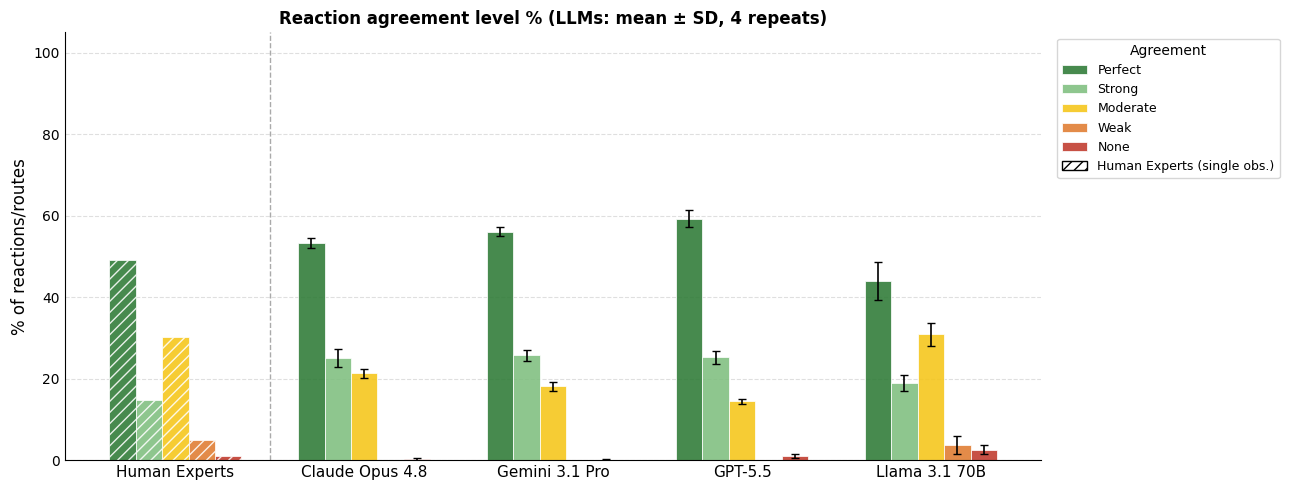

Saved results/averaged_agreement_reaction.png
Analyzing re-runs for 4 LLMs
Total LLM feedback entries: 3989
LLM-reaction pairs with 2+ re-runs: 199
Analyzing re-runs for 4 LLMs
Total LLM feedback entries: 3991
LLM-reaction pairs with 2+ re-runs: 199
Analyzing re-runs for 4 LLMs
Total LLM feedback entries: 3976
LLM-reaction pairs with 2+ re-runs: 199
Analyzing re-runs for 4 LLMs
Total LLM feedback entries: 3989
LLM-reaction pairs with 2+ re-runs: 200

=== Route — Agreement levels (mean % ± SD) ===
  Claude Opus 4.8       Perfect: 59.5±6.6  Strong: 30.0±4.9  Moderate: 10.5±3.4  Weak: 0.0±0.0  None: 0.0±0.0
  Gemini 3.1 Pro        Perfect: 58.0±5.2  Strong: 28.5±5.7  Moderate: 13.5±1.9  Weak: 0.0±0.0  None: 0.0±0.0
  GPT-5.5               Perfect: 69.5±6.6  Strong: 22.0±7.5  Moderate: 8.5±4.1  Weak: 0.0±0.0  None: 0.0±0.0
  Llama 3.1 70B         Perfect: 49.7±1.9  Strong: 25.9±4.2  Moderate: 23.4±4.4  Weak: 1.0±2.0  None: 0.0±0.0
Analyzing agreement for 16 human experts
Total human feedba

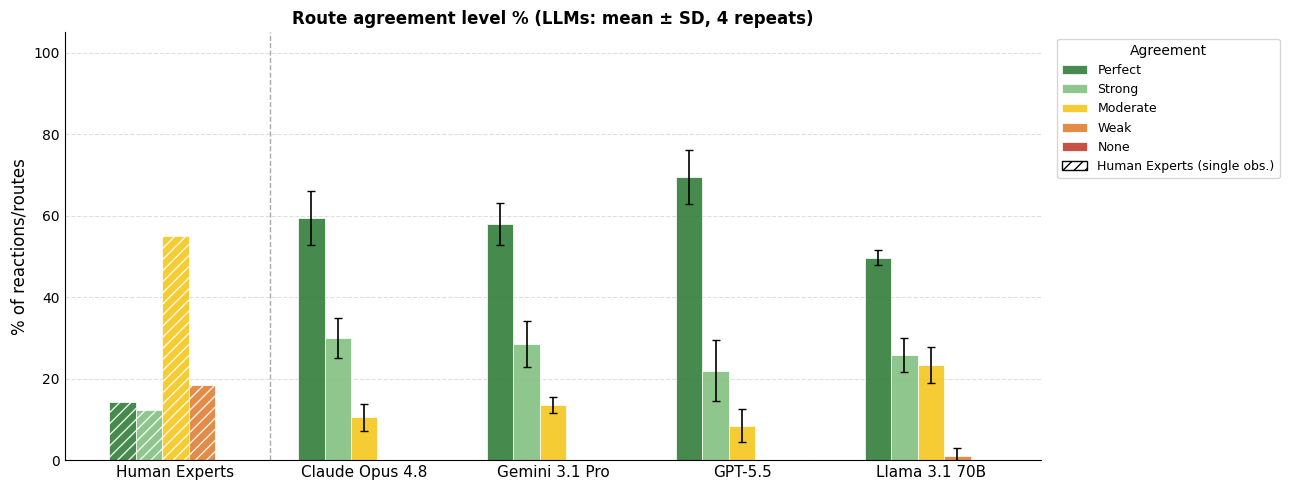

Saved results/averaged_agreement_route.png


In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
os.makedirs("results", exist_ok=True)

CSV             = "expert_feedback_combined_new_llms.csv"
LLM_IDENTIFIERS = ["Claude Opus 4.8", "Gemini 3.1 Pro", "GPT-5.5", "Llama 3.1 70B"]
AGREEMENT_LEVELS = ["Perfect", "Strong", "Moderate", "Weak", "None"]
LEVEL_COLORS     = {
    "Perfect":  "#2d7a35",
    "Strong":   "#7fbf7f",
    "Moderate": "#f5c518",
    "Weak":     "#e07b30",
    "None":     "#c0392b",
}

df = pd.read_csv(CSV)

def _avg_agreement(hash_col, cat_col, text_col, analysis_type):
    """
    For each repeat, run analyze_llm_internal_agreement (repeat filtered),
    extract the % of reactions at each agreement level per LLM,
    then average and compute SD across repeats.
    Returns a DataFrame: rows=LLM, cols=agreement levels, values=(mean, sd) tuples.
    Also plots a grouped bar chart and prints a summary table.
    """
    repeats = sorted(df[df["source_file"].isin(LLM_IDENTIFIERS)]["repeat"]
                     .dropna().unique().astype(int))

    # {llm: {level: [pct_r0, pct_r1, ...]}}
    pct_by_llm_level = {llm: {lv: [] for lv in AGREEMENT_LEVELS}
                        for llm in LLM_IDENTIFIERS}

    for r in repeats:
        result = analyze_llm_internal_agreement(
            df,
            hash_column=hash_col,
            category_column=cat_col,
            expert_column="source_file",
            text_column=text_col,
            llm_order=tuple(LLM_IDENTIFIERS),
            llm_repeat=r,
        )
        if not result or "reactions_df" not in result:
            continue
        rdf = result["reactions_df"]
        for llm in LLM_IDENTIFIERS:
            sub = rdf[rdf["llm_name"] == llm]
            total = len(sub)
            if total == 0:
                for lv in AGREEMENT_LEVELS:
                    pct_by_llm_level[llm][lv].append(np.nan)
                continue
            counts = sub["agreement_level"].value_counts()
            for lv in AGREEMENT_LEVELS:
                pct_by_llm_level[llm][lv].append(counts.get(lv, 0) / total * 100)

    # Build summary DataFrame
    rows = []
    for llm in LLM_IDENTIFIERS:
        row = {"Model": llm}
        for lv in AGREEMENT_LEVELS:
            vals = [v for v in pct_by_llm_level[llm][lv] if not np.isnan(v)]
            mean = np.mean(vals) if vals else np.nan
            sd   = np.std(vals, ddof=1) if len(vals) > 1 else 0.0
            row[f"{lv}_mean"] = round(mean, 1)
            row[f"{lv}_sd"]   = round(sd, 1)
        rows.append(row)
    summary = pd.DataFrame(rows)
    summary.to_csv(f"results/averaged_agreement_{analysis_type.lower()}.csv", index=False)

    print(f"\n=== {analysis_type} — Agreement levels (mean % ± SD) ===")
    for _, r in summary.iterrows():
        parts = [f"{lv}: {r[f'{lv}_mean']}±{r[f'{lv}_sd']}"
                 for lv in AGREEMENT_LEVELS]
        print(f"  {r['Model']:20s}  " + "  ".join(parts))

    # ── Human expert agreement (single observation, no repeats) ─────────────
    h_result = analyze_human_internal_agreement(
        df,
        hash_column=hash_col,
        category_column=cat_col,
        expert_column="source_file",
        text_column=text_col,
        llm_order=tuple(LLM_IDENTIFIERS),
    )
    human_pcts = {}
    if h_result and "human_agreement_df" in h_result:
        hdf = h_result["human_agreement_df"]
        total_h = len(hdf)
        if total_h > 0:
            counts_h = hdf["agreement_level"].value_counts()
            for lv in AGREEMENT_LEVELS:
                human_pcts[lv] = counts_h.get(lv, 0) / total_h * 100

    # Print human summary
    if human_pcts:
        parts = [f"{lv}: {human_pcts[lv]:.1f}%" for lv in AGREEMENT_LEVELS]
        print(f"  {'Human Experts':20s}  " + "  ".join(parts))

    # ── Plot: grouped bar chart with humans as first group ───────────────────
    all_groups  = ["Human Experts"] + LLM_IDENTIFIERS
    n_groups    = len(all_groups)
    n_levs      = len(AGREEMENT_LEVELS)
    x           = np.arange(n_groups)
    width       = 0.14
    offsets     = np.linspace(-(n_levs - 1) / 2, (n_levs - 1) / 2, n_levs) * width

    # Build arrays: humans have no SD (single observation → no error bar)
    means_all = {}
    sds_all   = {}
    for lv in AGREEMENT_LEVELS:
        h_val = human_pcts.get(lv, np.nan)
        llm_means = summary[f"{lv}_mean"].values
        llm_sds   = summary[f"{lv}_sd"].values
        means_all[lv] = np.array([h_val] + list(llm_means))
        sds_all[lv]   = np.array([0.0]   + list(llm_sds))

    fig, ax = plt.subplots(figsize=(13, 5))
    for k, lv in enumerate(AGREEMENT_LEVELS):
        m = means_all[lv]
        s = sds_all[lv]
        # Human bar: hatched to signal "no repeat uncertainty"
        ax.bar(x[0] + offsets[k], m[0], width,
               color=LEVEL_COLORS[lv], alpha=0.88,
               edgecolor="white", linewidth=0.6, hatch="///")
        # LLM bars: solid
        ax.bar(x[1:] + offsets[k], m[1:], width,
               color=LEVEL_COLORS[lv], alpha=0.88,
               label=lv, edgecolor="white", linewidth=0.6)
        # Error bars for LLMs only
        llm_sd_nonzero = np.where(s[1:] > 0, s[1:], np.nan)
        ax.errorbar(x[1:] + offsets[k], m[1:], yerr=llm_sd_nonzero,
                    fmt="none", color="black", capsize=3, linewidth=1.2)

    # Vertical separator between humans and LLMs
    ax.axvline(x=0.5, color="#aaaaaa", linewidth=1.0, linestyle="--")

    ax.set_xticks(x)
    ax.set_xticklabels(all_groups, fontsize=11)
    ax.set_ylabel("% of reactions/routes", fontsize=12)
    ax.set_ylim(0, 105)
    ax.set_title(f"{analysis_type} agreement level % (LLMs: mean ± SD, 4 repeats)",
                 fontsize=12, fontweight="bold")

    # Legend: agreement levels + hatch note
    handles, labels = ax.get_legend_handles_labels()
    import matplotlib.patches as mpatches
    hatch_note = mpatches.Patch(facecolor="white", edgecolor="black",
                                hatch="///", label="Human Experts (single observation)")
    ax.legend(handles=handles + [hatch_note],
              labels=labels + ["Human Experts (single obs.)"],
              title="Agreement", fontsize=9, title_fontsize=10,
              bbox_to_anchor=(1.01, 1), loc="upper left")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(length=0)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)
    plt.tight_layout()
    out = f"results/averaged_agreement_{analysis_type.lower()}.png"
    plt.savefig(out, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved {out}")
    return summary, human_pcts

summary_rxn,   human_rxn   = _avg_agreement("reaction_hash",      "local_feedback",   "local_feedback_text",   "Reaction")
summary_route, human_route = _avg_agreement("root_molecule_hash",  "general_feedback", "general_feedback_text", "Route")
